In [62]:
import numpy as np
import matplotlib.pyplot as plt
import expansion as ex
import ODESolve_slow as ODE
from constants import GF, gA, me, hbar, dmnp, mpl, mN, zeta3
import weakrates as weak
import expansion as ex

In [64]:
def f(a,y,p):
    
    T , t , Yp , Yn , eta = y
    der = np.zeros(5)

    der[0] = -(3*a**2*ex.sth(T))/(a**3*ex.dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ex.ptot(T,a))/(3*(mpl)**2))**(1/2)
    der[2] = (Yn*weak.Nnptot(T,a)-Yp*weak.Npntot(T,a))*der[1]
    der[3] = (-Yn*weak.Nnptot(T,a)+Yp*weak.Npntot(T,a))*der[1]
    der[4] = -3*eta*((1/T)*der[0]+(1/a))

    return der

In [66]:
a0 = 0.1    
y0 = np.array([10,0,0,0,(6.1e-10)*(11/4)],dtype=np.double)
y0[2] = (1+(weak.Npntot(y0[0],a0))/(weak.Nnptot(y0[0],a0)) )**(-1)
y0[3] = 1- y0[2]
p=None
dx0=0.001

N_step = 1000
dN = 2
x_final = 100




a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

True


In [67]:
g = np.array([0, 0 ,3, 2, 2, 1, 4, 4, 3], dtype=np.double)
B = np.array([0, 0, 2.22, 8.48, 7.72, 28.3, 37.6, 39.25, 31.99], dtype=np.double)
Z = np.array([0, 0, 1, 1, 2, 2, 4, 3, 3], dtype=np.double)
A = np.array([0, 0, 2, 3, 3, 4, 7, 7, 6], dtype=np.double)

In [68]:
print(y[4])
print(y[0])


[9.95533319e+00 1.00803446e+17 5.32411950e-01 4.67588050e-01
 1.67749728e-09]
[1.0000000e+01 0.0000000e+00 5.3228004e-01 4.6771996e-01 1.6775000e-09]


In [69]:
nB=y[:,4]*(3/2)*zeta3*y[:,0]**3
epsilon=(1/2)*((2*np.pi)/mN*y[0,0])**(3/2)*nB
print(nB)
print(epsilon)

[3.02467568e-06 3.02008324e-06 3.01268403e-06 3.00189241e-06
 2.98432083e-06 2.96071101e-06 2.93864102e-06 2.91610305e-06
 2.89371257e-06 2.87136878e-06 2.84904255e-06 2.82677720e-06
 2.80454500e-06 2.78236105e-06 2.76021943e-06 2.73812317e-06
 2.71607195e-06 2.69406653e-06 2.67210741e-06 2.65019514e-06
 2.62833024e-06 2.60651329e-06 2.58474481e-06 2.56302538e-06
 2.54135554e-06 2.51973586e-06 2.49816691e-06 2.47664924e-06
 2.45518344e-06 2.43377008e-06 2.41240972e-06 2.39110296e-06
 2.36985037e-06 2.34865254e-06 2.32751006e-06 2.30642351e-06
 2.28539349e-06 2.26442059e-06 2.24350541e-06 2.22264855e-06
 2.20185060e-06 2.18111217e-06 2.16043386e-06 2.13981627e-06
 2.11926002e-06 2.09876571e-06 2.07833394e-06 2.05796533e-06
 2.03766049e-06 2.01742002e-06 1.99724455e-06 1.97713467e-06
 1.95709101e-06 1.93711418e-06 1.91720479e-06 1.89736345e-06
 1.87759077e-06 1.85788737e-06 1.83825387e-06 1.81869086e-06
 1.79919897e-06 1.77977880e-06 1.76043097e-06 1.74115608e-06
 1.72195474e-06 1.702827

In [89]:
Y=np.zeros((9,len(a)))
Y[0,:] = y[:,2]
Y[1,:] = y[:,3]
for i in range(2,9):
    Y[i,:]=(1/2)*y[:,2]**Z[i]*y[:,3]**(A[i]-Z[i])*g[i]*A[i]**(3/2)*epsilon**(A[i]-1)*np.exp(B[i]/y[:,0])




/var/folders/wh/zy977ds93ps0947h9g20l8ch0000gr/T/ipykernel_39615/3632452713.py:5: RuntimeWarning: overflow encountered in exp
  Y[i,:]=(1/2)*y[:,2]**Z[i]*y[:,3]**(A[i]-Z[i])*g[i]*A[i]**(3/2)*epsilon**(A[i]-1)*np.exp(B[i]/y[:,0])


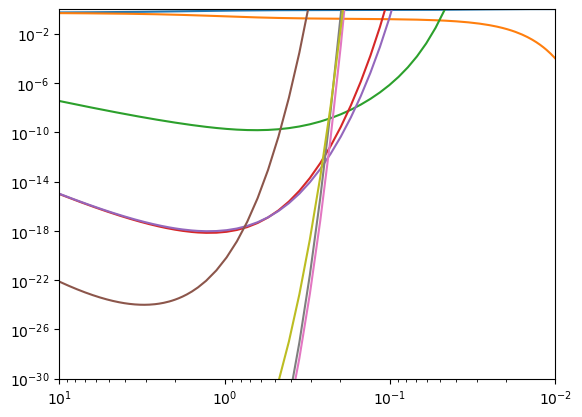

In [107]:
Tcm = np.zeros(len(a))
for i in range(len(Tcm)):
    Tcm[i]=1/a[i]

plt.figure()
for i in range(9):
    plt.loglog(Tcm,Y[i,:])
    plt.ylim(1e-30,1)
    plt.xlim(10,1e-2)

[0.53228004 0.5322873  0.53231071 0.53234885 0.53241195 0.53249753
 0.53257835 0.53266173 0.53274541 0.53282977 0.53291495 0.53300078
 0.53308739 0.53317472 0.53326282 0.53335167 0.5334413  0.53353171
 0.53362291 0.53371492 0.53380774 0.53390138 0.53399586 0.53409119
 0.53418737 0.53428443 0.53438236 0.53448119 0.53458092 0.53468157
 0.53478315 0.53488567 0.53498915 0.53509359 0.53519902 0.53530544
 0.53541287 0.53552133 0.53563082 0.53574137 0.53585298 0.53596568
 0.53607947 0.53619438 0.53631042 0.53642761 0.53654596 0.5366655
 0.53678623 0.53690818 0.53703137 0.53715581 0.53728153 0.53740853
 0.53753685 0.5376665  0.53779751 0.53792989 0.53806367 0.53819886
 0.5383355  0.5384736  0.53861319 0.5387543  0.53889694 0.53904114
 0.53918693 0.53933433 0.53948338 0.5396341  0.53978652 0.53994066
 0.54009656 0.54025425 0.54041375 0.54057511 0.54073835 0.54090352
 0.54107063 0.54123973 0.54141086 0.54158404 0.54175933 0.54193676
 0.54211636 0.54229819 0.54248228 0.54266868 0.54285744 0.54304